In [29]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
from datataking import search_datadict_miyamura
from Analysis import WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit
import time as T

cd = "CDK183"
data_path = f"D:\\K_Sunada\\result\\{cd}"

data_tx = "/2025-07-16/2025-07-16T110938_ed79c901-b00_spectrum"
dd_tx = datadict_from_hdf5(data_path + data_tx +"/data")
freq_tx = dd_tx['probe_frequency']['values']*1e9
s11_g_tx = dd_tx['s11_g']['values']
s11_e_tx = dd_tx['s11_e']['values']
s11_eg_div_tx = s11_e_tx / s11_g_tx

data_rx = "/2025-07-16/2025-07-16T145328_31f4b5a8-b00_spectrum"
dd_rx = datadict_from_hdf5(data_path + data_rx +"/data")
freq_rx = dd_rx['probe_frequency']['values']*1e9
s11_g_rx = dd_rx['s11_g']['values']
s11_e_rx = dd_rx['s11_e']['values']
s11_eg_div_rx = s11_e_rx / s11_g_rx

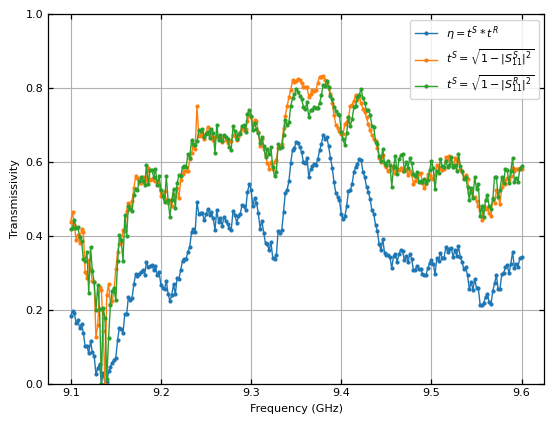

In [42]:
abs_s11_tx = np.abs(s11_g_tx)
abs_s11_rx = np.abs(s11_g_rx)

ref_s = abs_s11_tx/np.max(abs_s11_tx)
ref_r = abs_s11_rx/np.max(abs_s11_rx)

trans_s = np.sqrt(1 - ref_s**2)
trans_r = np.sqrt(1 - ref_r**2)

eta = trans_s * trans_r

# プロット
plt.plot(freq_tx * 1e-9, eta, marker='o', label=r"$\eta = t^S*t^R$")
plt.plot(freq_tx * 1e-9, trans_s, marker='o', label=r"$t^S=\sqrt{1 - |S_{11}^S|^2}$")
plt.plot(freq_rx * 1e-9, trans_r, marker='o', label=r"$t^S=\sqrt{1 - |S_{11}^R|^2}$")

# plt.xlim(9.31, 9.39)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmissivity")
plt.grid(True)
plt.ylim(0, 1)
plt.legend()
# plt.title("Estimated transmissivity from S11 measurements")

plt.show()

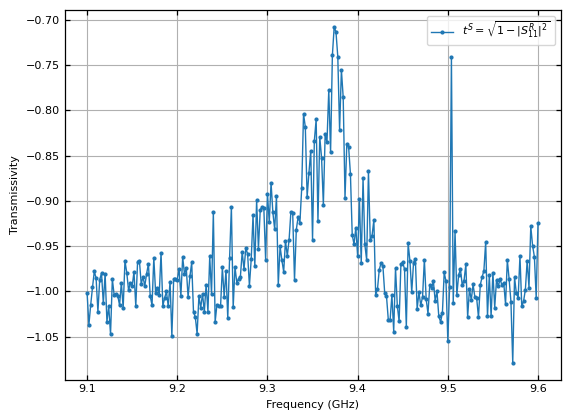

In [39]:
abs_s11_tx = np.abs(s11_g_tx)
abs_s11_rx = np.abs(s11_g_rx)

ref_s = abs_s11_tx/np.max(abs_s11_tx)
ref_r = abs_s11_rx/np.max(abs_s11_rx)

trans_s = np.sqrt(1 - ref_s**2)
trans_r = np.sqrt(1 - ref_r**2)

eta = trans_s * trans_r

# プロット
# plt.plot(freq_tx * 1e-9, 1-s11_eg_div_tx, marker='o', label=r"$\eta = t^S*t^R$")
# plt.plot(freq_tx * 1e-9, 1-s11_eg_div_rx, marker='o', label=r"$t^S=\sqrt{1 - |S_{11}^S|^2}$")
plt.plot(freq_rx * 1e-9,  -s11_eg_div_tx*s11_eg_div_rx, marker='o', label=r"$t^S=\sqrt{1 - |S_{11}^R|^2}$")



# plt.xlim(9.31, 9.39)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmissivity")
plt.grid(True)
# plt.ylim(0, 1)
plt.legend()
# plt.title("Estimated transmissivity from S11 measurements")

plt.show()

In [4]:
from scipy.special import gamma, zeta
import matplotlib.pyplot as plt

kappa = 2.5e-3*2*np.pi*2

def N_m(m, kappa=kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

# A_list[m] has the coefficients of A_m(t)([a0, a1, ..., am] (t^0, t^1, ..., t^m))
A_list = {}
Z_list = {}

A_list[0] = [1.0]
Z_dict = {
    0: kappa / 4,
    }

def compute_Z_m(m, A_coeffs):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = N_m(Nj_index)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1/Z

def get_A_m(m):
    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = get_A_m(lower_m)

        # sum over j
        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = N_m(m - (i + j))
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = compute_Z_m(m, A_m_coeffs)
    print("Z_m", Z_m, m, A_m_coeffs)
    Z_dict[m] = Z_m

    A_list[m] = A_m_coeffs
    return A_m_coeffs

def sech(x):
    return 1 / np.cosh(x)

def xi_m(t, m, kappa):
    A_coeffs = get_A_m(m)
    Zm = Z_dict[m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

Z_m 2.3561944901923456e-06 1 [0.0, 1.0]
Z_m 2.2089323345553242e-10 2 [-3333.3333333333326, 0.0, 1.0]
Z_m 9.54476934684399e-15 3 [0.0, -13999.999999999998, 0.0, 1.0]
Z_m 2.348908081449889e-19 4 [77142857.14285716, 0.0, -37142.85714285715, 0.0, 1.0]
Z_m 3.7206704010166296e-24 5 [0.0, 646031746.0317459, 0.0, -77777.77777777778, 0.0, 1.0]
Z_m 4.1053693468007393e-29 6 [-4870129870129.864, 0.0, 2990909090.909087, 0.0, -140909.0909090908, 0.0, 1.0]
Z_m 3.3342233345529004e-34 7 [0.0, -63419580419580.66, 0.0, 10039860139.86017, 0.0, -231538.46153846185, 0.0, 1.0]
Z_m 2.0757493904076642e-39 8 [5.99650349650344e+17, 0.0, -431684848484845.1, 0.0, 27389743589.743458, 0.0, -354666.666666666, 0.0, 1.0]
Z_m 1.0218976575242988e-44 9 [0.0, 1.0786575894693693e+19, 0.0, -2044361990950247.5, 0.0, 64581176470.588585, 0.0, -515294.1176470599, 0.0, 1.0]


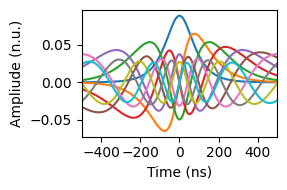

In [5]:


def sech(x):
    return 1 / np.cosh(x)

def xi_m(t, m, kappa):
    A_coeffs = get_A_m(m)
    Zm = Z_dict[m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

duration = 1000
t_vals = np.linspace(-duration/2, duration/2, duration)

plt.figure(figsize=(3, 2))

for m in range(10):
    y_vals = [xi_m(t, m, kappa) for t in t_vals]
    plt.plot(t_vals, y_vals, label=f'm={m}')

plt.xlabel('Time (ns)')
plt.ylabel('Ampliude (n.u.)')
# plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
plt.xlim(-duration/2, duration/2)
# plt.savefig("Figapp2_a.pdf")
# plt.savefig("Figapp2_a_tw.pdf")
plt.show()

In [6]:
from Analysis import separability, overlap
def plot_squaredI_matrix(waveform_envelope, mode_num):
    expI_matrix = np.zeros((mode_num, mode_num))
    I_normalized = np.zeros((mode_num, mode_num))
    for m in range(mode_num):
        for m_prime in range(mode_num):
            wf_m = waveform_envelope[m]
            wf_m_prime = waveform_envelope[m_prime]
            expI_matrix[m, m_prime] = overlap(wf_m, wf_m_prime)
            norm_product = np.linalg.norm(wf_m) * np.linalg.norm(wf_m_prime)
            I_normalized[m, m_prime] = expI_matrix[m, m_prime] / norm_product
    
    squaredI_matrix = I_normalized**2
    plt.figure(figsize=(4, 2))
    plt.imshow(squaredI_matrix, cmap='viridis', origin='lower', vmin=0, vmax=1)
    for i in range(mode_num):
        for j in range(mode_num):
            if i != j:
                if squaredI_matrix[j, i]>0.5:
                    plt.text(i, j, f"{np.round(squaredI_matrix[j, i], decimals=2)}", ha='center', va='center', color="red")
                else:
                    plt.text(i, j, f"{np.round(squaredI_matrix[j, i], decimals=2)}", ha='center', va='center', color="white")

    plt.colorbar(label=r'Squared overlap $|I_{m, m^{\prime}}|^2$')
    plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
    plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
    plt.rcParams['font.size'] = 8 #フォントの大きさ
    plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
    plt.rcParams['xtick.top'] = True
    plt.rcParams['xtick.bottom'] = True
    plt.rcParams['ytick.left'] = True
    plt.rcParams['ytick.right'] = True
    plt.rcParams['lines.linewidth'] = 1
    plt.rcParams['lines.markersize'] = 2.
    plt.xlabel(r"Photon mode $m^{\prime}$")
    plt.ylabel(r"Photon mode $m$")
    plt.xticks(range(len(squaredI_matrix)))
    plt.yticks(range(len(squaredI_matrix)))
    plt.tight_layout()
    # plt.savefig('Fig2_c.pdf', bbox_inches='tight')
    # print("basis_fidelity:", basis_fidelity(expI_matrix))
    print("separability:", separability(expI_matrix))
    return I_normalized, waveform_envelope

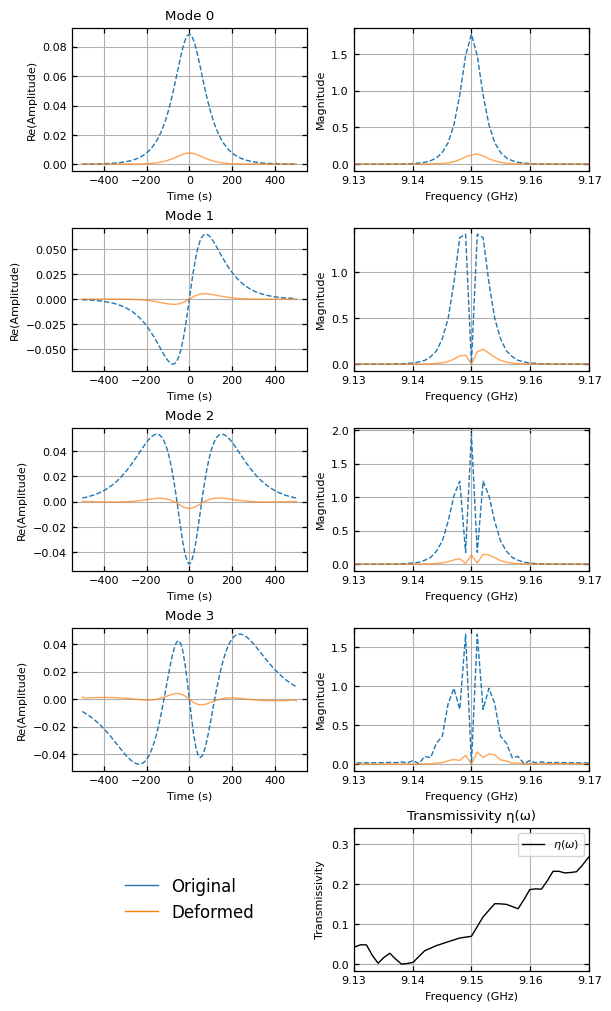

separability: (0.9999999205433769, [0.9999999998484559, 0.9999998423861711, 0.9999999998482739, 0.9999998400906065])
separability: (0.7474989357856301, [0.7610661173261981, 0.7332035442486368, 0.6877648818688938, 0.8079611996987915])


(array([[1.        , 0.41472671, 0.25790345, 0.12233963],
        [0.41472671, 1.        , 0.43676138, 0.21039562],
        [0.25790345, 0.43676138, 1.        , 0.43587044],
        [0.12233963, 0.21039562, 0.43587044, 1.        ]]),
 [array([-7.36012912e-05+1.06013258e-06j, -7.31621003e-05+8.43512878e-06j,
         -7.36756213e-05+1.62454907e-05j, -7.46844103e-05+2.41722797e-05j,
         -7.61858541e-05+3.19951871e-05j, -7.79958200e-05+3.97384949e-05j,
         -8.00588385e-05+4.74610081e-05j, -8.23413650e-05+5.47024022e-05j,
         -8.46459516e-05+6.13067538e-05j, -8.68098034e-05+6.73226034e-05j,
         -8.89796488e-05+7.21256539e-05j, -9.07084837e-05+7.60434303e-05j,
         -9.24651150e-05+7.87526620e-05j, -9.36680421e-05+8.02118905e-05j,
         -9.40713881e-05+8.12957325e-05j, -9.41418391e-05+8.15145670e-05j,
         -9.31224954e-05+8.08164102e-05j, -9.07609018e-05+7.99989254e-05j,
         -8.86571957e-05+7.82390748e-05j, -8.65830449e-05+7.49296716e-05j,
         -8.4358

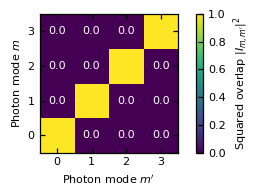

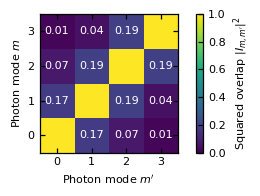

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fftshift, ifft

duration = 1000
t = np.linspace(-duration/2, duration/2, 101)
dt = t[1] - t[0]
photon_freq = 9.15e9
omega_0 = 2 * np.pi * photon_freq

freq = fftshift(fftfreq(len(t), d=dt)) * 2 * np.pi

freq_Hz = freq / (2 * np.pi)+photon_freq*1e-9
eta_on_freq_Hz = np.interp(freq_Hz, freq_tx*1e-9, eta) 
mode_num = 4

fig, axs = plt.subplots(mode_num + 1, 2, figsize=(6, 2*(mode_num+1)), constrained_layout=True)
original_wavforms = []
deformed_wavforms = []

for m in range(mode_num):
    xi_t = xi_m(t, m, kappa) * np.exp(-1j * omega_0 * t)
    xi_w = fftshift(fft(xi_t))
    deformed_w = xi_w * eta_on_freq_Hz
    deformed_t = ifft(fftshift(deformed_w))

    ax_time = axs[m, 0]
    ax_time.plot(t, np.real(xi_t), linestyle='--', label='Original')
    ax_time.plot(t, -np.real(deformed_t), linestyle='-', label='Deformed', alpha=0.7)
    ax_time.set_title(f"Mode {m}")
    ax_time.set_xlabel("Time (s)")
    ax_time.set_ylabel("Re(Amplitude)")
    # ax_time.legend()
    ax_time.grid(True)
    original_wavforms.append(xi_t)
    deformed_wavforms.append(deformed_t)

    ax_freq = axs[m, 1]
    ax_freq.plot(freq_Hz, np.abs(xi_w), linestyle='--', label='Original')
    ax_freq.plot(freq_Hz, np.abs(deformed_w), linestyle='-', label='Deformed', alpha=0.7)
    # ax_freq.set_title(f"Mode {m}")
    ax_freq.set_xlabel("Frequency (GHz)")
    ax_freq.set_ylabel("Magnitude")
    ax_freq.set_xlim(photon_freq*1e-9-0.02, photon_freq*1e-9+0.02)
    # ax_freq.legend()
    ax_freq.grid(True)

ax_eta_time = axs[-1, 0]
ax_eta_time.axis('off')  

ax_eta_freq = axs[-1, 1]
ax_eta_freq.plot(freq_Hz, eta_on_freq_Hz, color='black', label=r'$\eta(\omega)$')
ax_eta_freq.set_title("Transmissivity η(ω)")
ax_eta_freq.set_xlabel("Frequency (GHz)")
ax_eta_freq.set_ylabel("Transmissivity")
ax_eta_freq.legend()
ax_eta_freq.set_xlim(photon_freq*1e-9-0.02, photon_freq*1e-9+0.02)
ax_eta_freq.grid(True)

line_original, = ax_eta_time.plot([], [], color='C0', label='Original')
line_deformed, = ax_eta_time.plot([], [], color='C1', label='Deformed')

ax_eta_time.legend(handles=[line_original, line_deformed], loc='center', frameon=False, fontsize=12)

plt.show()

plot_squaredI_matrix(original_wavforms, mode_num)
plot_squaredI_matrix(deformed_wavforms, mode_num)

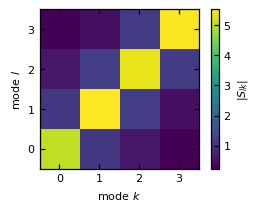

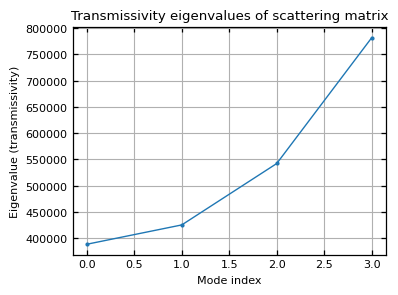

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fftshift, ifft


dt = t[1] - t[0]

# --- 実験透過率 η(ω) を補間して準備 ---
omega = 2 * np.pi * freq_Hz * 1e9  # 周波数 [rad/s]
domega = omega[1] - omega[0]

# --- 周波数モード関数 f_m(ω) を作成 ---
f_w_list = []
for m in range(mode_num):
    xi_t = xi_m(t, m, kappa) * np.exp(-1j * omega_0 * t)
    f_w = fftshift(fft(xi_t))
    f_w = f_w / np.linalg.norm(f_w)  # L2ノルムで正規化
    f_w_list.append(f_w)

# --- 散乱行列 S_{lk} を計算 ---
S = np.zeros((mode_num, mode_num), dtype=complex)
for l in range(mode_num):
    for k in range(mode_num):
        integrand = eta_on_freq_Hz * np.conj(f_w_list[k]) * f_w_list[l]
        S[l, k] = np.sum(integrand) * domega

fig, ax = plt.subplots(1, 1, figsize=(3, 2), constrained_layout=True)

# 絶対値
im2 = ax.imshow(np.abs(S)*1e-5, cmap='viridis', origin='lower')
# ax.set_title(r"$|S_{lk}|$")
ax.set_xlabel(r"mode $k$")
ax.set_ylabel(r"mode $l$")
fig.colorbar(im2, ax=ax, label=r"$|S_{lk}|$")

# plt.suptitle("Scattering Matrix $S_{lk}$", fontsize=14)
plt.show()

# --- S の固有値分解 ---
eigvals, U = np.linalg.eigh(S)

# --- 最適周波数モード（固有モード）を計算 ---
optimal_f_w_list = []
for m in range(mode_num):
    optimal_f_w = sum(U[m, k] * f_w_list[k] for k in range(mode_num))
    optimal_f_w_list.append(optimal_f_w)

# --- 時間領域に戻す（必要なら） ---
optimal_xi_t_list = [ifft(fftshift(f_w)) for f_w in optimal_f_w_list]

# --- プロット（例：固有値と各最適モード） ---
plt.figure(figsize=(4, 3))
plt.plot(np.arange(mode_num), eigvals, 'o-')
plt.xlabel("Mode index")
plt.ylabel("Eigenvalue (transmissivity)")
plt.title("Transmissivity eigenvalues of scattering matrix")
plt.grid(True)
plt.tight_layout()
plt.show()



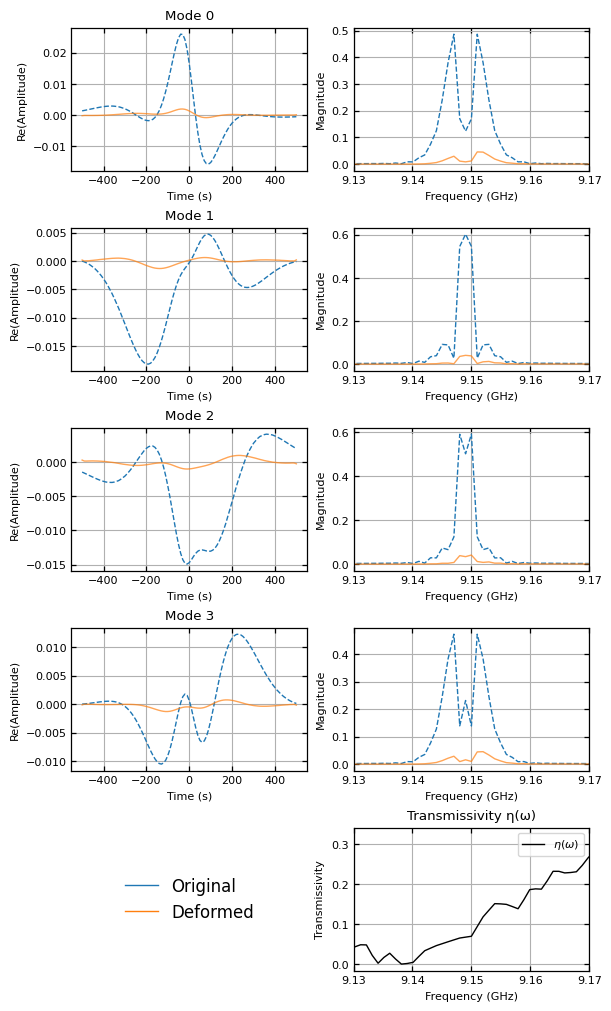

separability: (0.9999999560300614, [0.9999999442628704, 0.9999999563512533, 0.9999999587450721, 0.9999999647610501])
separability: (0.8604878832043752, [0.7610865133577777, 0.9543631269588366, 0.967792904955273, 0.7587089875456132])


(array([[1.        , 0.10352063, 0.09390545, 0.54886212],
        [0.10352063, 1.        , 0.05933913, 0.13153426],
        [0.09390545, 0.05933913, 1.        , 0.09927847],
        [0.54886212, 0.13153426, 0.09927847, 1.        ]]),
 [array([ 1.72649564e-04-1.20540720e-04j,  9.87054061e-05-3.05156247e-05j,
          9.35765954e-05-4.62856514e-05j,  9.91175925e-05-4.91572556e-05j,
          9.94972505e-05-7.49369667e-05j,  1.00484374e-04-9.43877249e-05j,
          9.23631702e-05-1.17913872e-04j,  8.24292998e-05-1.38971019e-04j,
          6.67427565e-05-1.71951029e-04j,  5.01947304e-05-1.91507877e-04j,
          2.39882884e-05-2.13773462e-04j,  2.05984684e-06-2.34968636e-04j,
         -3.69814474e-05-2.55883590e-04j, -7.73821198e-05-2.73936987e-04j,
         -1.15068776e-04-2.88091735e-04j, -1.58709031e-04-2.91688650e-04j,
         -2.12029191e-04-2.93797990e-04j, -2.58727559e-04-2.90472462e-04j,
         -3.14238019e-04-2.72084919e-04j, -3.68836858e-04-2.47427091e-04j,
         -4.1453

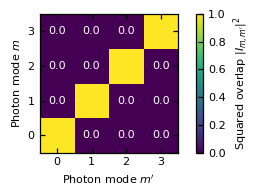

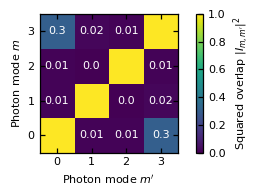

In [ ]:

fig, axs = plt.subplots(mode_num + 1, 2, figsize=(6, 2*(mode_num+1)), constrained_layout=True)
original_wavforms = []
deformed_wavforms = []

for m in range(mode_num):
    xi_t = optimal_xi_t_list[m] * np.exp(-1j * omega_0 * t)
    xi_w = fftshift(fft(xi_t))
    deformed_w = xi_w * eta_on_freq_Hz
    deformed_t = ifft(fftshift(deformed_w))

    ax_time = axs[m, 0]
    ax_time.plot(t, np.real(xi_t), linestyle='--', label='Original')
    ax_time.plot(t, -np.real(deformed_t), linestyle='-', label='Deformed', alpha=0.7)
    ax_time.set_title(f"Mode {m}")
    ax_time.set_xlabel("Time (s)")
    ax_time.set_ylabel("Re(Amplitude)")
    # ax_time.legend()
    ax_time.grid(True)
    original_wavforms.append(xi_t)
    deformed_wavforms.append(deformed_t)

    ax_freq = axs[m, 1]
    ax_freq.plot(freq_Hz, np.abs(xi_w), linestyle='--', label='Original')
    ax_freq.plot(freq_Hz, np.abs(deformed_w), linestyle='-', label='Deformed', alpha=0.7)
    # ax_freq.set_title(f"Mode {m} Frequency domain")
    ax_freq.set_xlabel("Frequency (GHz)")
    ax_freq.set_ylabel("Magnitude")
    ax_freq.set_xlim(photon_freq*1e-9-0.02, photon_freq*1e-9+0.02)
    # ax_freq.legend()
    ax_freq.grid(True)

ax_eta_time = axs[-1, 0]
ax_eta_time.axis('off')  

ax_eta_freq = axs[-1, 1]
ax_eta_freq.plot(freq_Hz, eta_on_freq_Hz, color='black', label=r'$\eta(\omega)$')
ax_eta_freq.set_title("Transmissivity η(ω)")
ax_eta_freq.set_xlabel("Frequency (GHz)")
ax_eta_freq.set_ylabel("Transmissivity")
ax_eta_freq.legend()
ax_eta_freq.set_xlim(photon_freq*1e-9-0.02, photon_freq*1e-9+0.02)
ax_eta_freq.grid(True)

line_original, = ax_eta_time.plot([], [], color='C0', label='Original')
line_deformed, = ax_eta_time.plot([], [], color='C1', label='Deformed')

ax_eta_time.legend(handles=[line_original, line_deformed], loc='center', frameon=False, fontsize=12)

plt.show()

plot_squaredI_matrix(original_wavforms, mode_num)
plot_squaredI_matrix(deformed_wavforms, mode_num)

In [ ]:
print("L2 inner product between optimal modes:")
for m in range(mode_num):
    for n in range(mode_num):
        overlap = np.vdot(optimal_f_w_list[m], optimal_f_w_list[n])
        print(f"<{m}|{n}> = {np.abs(overlap)**2:.3e}")


L2 inner product between optimal modes:
<0|0> = 1.000e+00
<0|1> = 1.350e-15
<0|2> = 1.371e-15
<0|3> = 6.497e-15
<1|0> = 1.350e-15
<1|1> = 1.000e+00
<1|2> = 6.516e-15
<1|3> = 1.345e-15
<2|0> = 1.371e-15
<2|1> = 6.516e-15
<2|2> = 1.000e+00
<2|3> = 1.457e-15
<3|0> = 6.497e-15
<3|1> = 1.345e-15
<3|2> = 1.457e-15
<3|3> = 1.000e+00
